# BLS (Batch Least Squares) — Modelo 1/4 Drone (V2 - Múltiplos Datasets)
**Metodologia:**
- Identificação com concatenação de 3 datasets de treinamento da RODADA-2
- Validação com concatenação de 2 datasets de validação da RODADA-2
- Objetivo: Achar o melhor (na, nb) generalizado para o Aeropêndulo

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.fft
from sklearn.metrics import mean_squared_error, r2_score

## 1. Ingestão e Pré-processamento dos Dados

In [2]:
def carregar_experimento(url, decimacao=1, start_idx=0, end_idx=None):
    df = pd.read_csv(url)
    df_sub = df.iloc[::decimacao].copy().reset_index(drop=True)
    if 'u_pct' in df_sub.columns:
        u_raw = df_sub['u_pct'].values
    else:
        u_raw = df_sub['motor_percent'].values
    y_raw = df_sub['angulo_deg'].values
    if end_idx is None:
        end_idx = len(u_raw)
    u = u_raw[start_idx:end_idx]
    y = y_raw[start_idx:end_idx]
    return u, y
    
BASE2 = (
    "https://raw.githubusercontent.com/FelipeEduardoMarcondes/"
    "SYSTEM-IDENTIFICATION-AERO/main/experimentos/"
)

train_files = [
    "RODADA-2/chirp-1_0804_19-19.csv",
    "RODADA-2/multi-seno-2_0804_19-28.csv",
    "RODADA-2/seq-degraus-1_0804_19-09.csv",
    "RODADA-3/multi-seno-1_0807_16-57.csv",
    "RODADA-3/multi-seno-2_0807_17-13.csv",
    "RODADA-3/seq-degraus-1_0807_16-38.csv",
    "RODADA-3/seq-degraus-aprbs-2_0807_17-23.csv",
    "RODADA-3/seq-dragus-aprbs_0807_16-50.csv"
]

val_files = [

    "RODADA-2/multi-seno-1_0804_19-06.csv",
    "RODADA-2/seq-degraus-2_0804_19-38.csv",
    "RODADA-2/multi-seno-3_0804_19-44.csv",
    "RODADA-2/seq-degraus-1_0804_19-12.csv"
]
# Limites de corte para remover ruído
CUT_TRA_START = 1500
CUT_TRA_END = -1400

CUT_TEST_START = 1500
CUT_TEST_END = -1400

print("Carregando datasets de treinamento...")
u_train_list, y_train_list = [], []
for f in train_files:
    u, y = carregar_experimento(BASE2 + f, start_idx=CUT_TRA_START, end_idx=CUT_TRA_END)
    u_train_list.append(u)
    y_train_list.append(y)

print("Carregando datasets de validação...")
u_val_list, y_val_list = [], []
for f in val_files:
    u, y = carregar_experimento(BASE2 + f, start_idx=CUT_TEST_START, end_idx=CUT_TEST_END)
    u_val_list.append(u)
    y_val_list.append(y)

print(f"Treinamento: {len(u_train_list)} datasets")
print(f"Validação: {len(u_val_list)} datasets")


Carregando datasets de treinamento...
Carregando datasets de validação...
Treinamento: 8 datasets
Validação: 4 datasets


## 2. Separação Treinamento / Validação (70% / 30%)

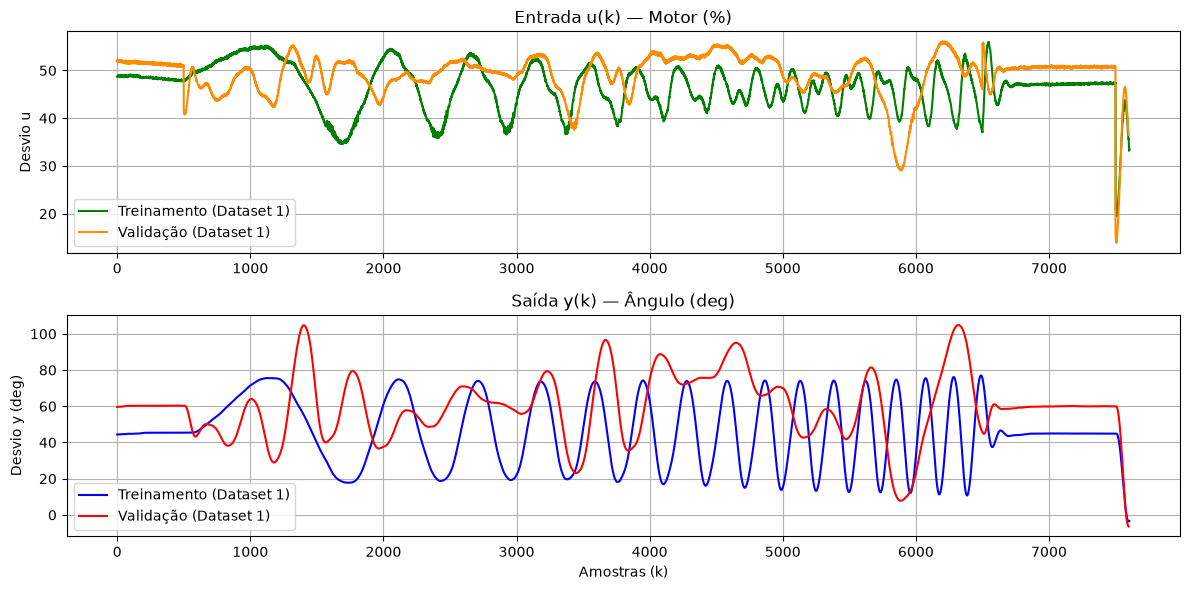

In [3]:
# Visualização (Apenas o primeiro dataset para não misturar no plot)
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(u_train_list[0],  color='green',      lw=1.5, label='Treinamento (Dataset 1)')
axes[0].plot(u_val_list[0], color='darkorange', lw=1.5, label='Validação (Dataset 1)')
axes[0].set_title('Entrada u(k) — Motor (%)')
axes[0].set_ylabel('Desvio u')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(y_train_list[0],  color='blue', lw=1.5, label='Treinamento (Dataset 1)')
axes[1].plot(y_val_list[0], color='red',  lw=1.5, label='Validação (Dataset 1)')
axes[1].set_title('Saída y(k) — Ângulo (deg)')
axes[1].set_ylabel('Desvio y (deg)')
axes[1].set_xlabel('Amostras (k)')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


## 3. Funções Auxiliares: Matriz de Regressão e Simulação Free-Run

In [4]:
def create_regression_matrix(u, y, na, nb):
    """
    Constrói a matriz de regressão Phi e o vetor alvo y_target
    para um modelo ARX de ordens na (saída) e nb (entrada).

    Linha de Phi em k: [-y(k-1), ..., -y(k-na), u(k-1), ..., u(k-nb)]
    """
    u = np.asarray(u).flatten()
    y = np.asarray(y).flatten()
    N = len(y)
    if N != len(u):
        raise ValueError("Dimensões de u e y inconsistentes!")

    p = max(na, nb)
    y_target = y[p:]
    Phi = np.zeros((N - p, na + nb))

    for i in range(1, na + 1):
        Phi[:, i - 1] = -y[p - i: N - i]
    for i in range(1, nb + 1):
        Phi[:, na + i - 1] = u[p - i: N - i]

    return Phi, y_target


def free_run_simulation(th_hat, u, y_measured, na, nb):
    """
    Simulação Free-Run: usa apenas saídas simuladas anteriores
    (sem realimentação das saídas medidas após as condições iniciais).
    """
    u = np.asarray(u).flatten()
    y_measured = np.asarray(y_measured).flatten()
    N = len(u)
    p = max(na, nb)
    y_sim = np.zeros(N)
    y_sim[:p] = y_measured[:p]   # condições iniciais = dados medidos

    for k in range(p, N):
        # Utilizando a função do passo 1 (create_regression_matrix) para construir o regressor.
        # Passamos uma janela de p+1 amostras (do instante k-p até k)
        u_window = u[k-p : k+1]
        y_window = y_sim[k-p : k+1]
        
        # A função retorna a matriz de regressão (Phi) com 1 linha e o vetor y_target.
        Phi_k_matrix, _ = create_regression_matrix(u_window, y_window, na, nb)
        
        # Faz a predição para o instante k
        y_sim[k] = Phi_k_matrix[0] @ th_hat

    return y_sim[p:]


def calcular_metricas(y_real, y_pred, label=""):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    print(f"  {label:30s} → RMSE: {rmse:.6e}  |  R²: {r2:.6f}")
    return rmse, r2


def espectro_amplitude(sinal, Ts):
    N   = len(sinal)
    xf  = scipy.fft.fftfreq(N, Ts)[:N // 2]
    amp = 2.0 / N * np.abs(scipy.fft.fft(sinal)[:N // 2])
    return xf, amp

## 4. Identificação BLS — Apenas Dados de Treinamento

In [5]:
na = 30
nb = 30

def build_global_regression(u_list, y_list, na, nb):
    Phi_all = []
    Y_all = []
    for u, y in zip(u_list, y_list):
        Phi, Y = create_regression_matrix(u, y, na, nb)
        Phi_all.append(Phi)
        Y_all.append(Y)
    return np.concatenate(Phi_all, axis=0), np.concatenate(Y_all, axis=0)

# Matrizes de regressão: TREINAMENTO e VALIDAÇÃO (Concatenadas)
Phi_TRA,  y_target_TRA  = build_global_regression(u_train_list, y_train_list, na, nb)
Phi_TEST, y_target_TEST = build_global_regression(u_val_list, y_val_list, na, nb)

# Estimação dos parâmetros SOMENTE com dados de treinamento concatenados
th_hat, _, _, _ = np.linalg.lstsq(Phi_TRA, y_target_TRA, rcond=None)

print("Parâmetros estimados pelo BLS (treinamento global):")
print(f"  a1 = {th_hat[0]:.6f}")
print(f"  a2 = {th_hat[1]:.6f}")
print(f"  b1 = {th_hat[2]:.6f}")
print(f"  b2 = {th_hat[3]:.6f}")


Parâmetros estimados pelo BLS (treinamento global):
  a1 = -1.399686
  a2 = 0.034068
  b1 = 0.181106
  b2 = 0.137429


## 5. Predição OSA — Treinamento e Validação

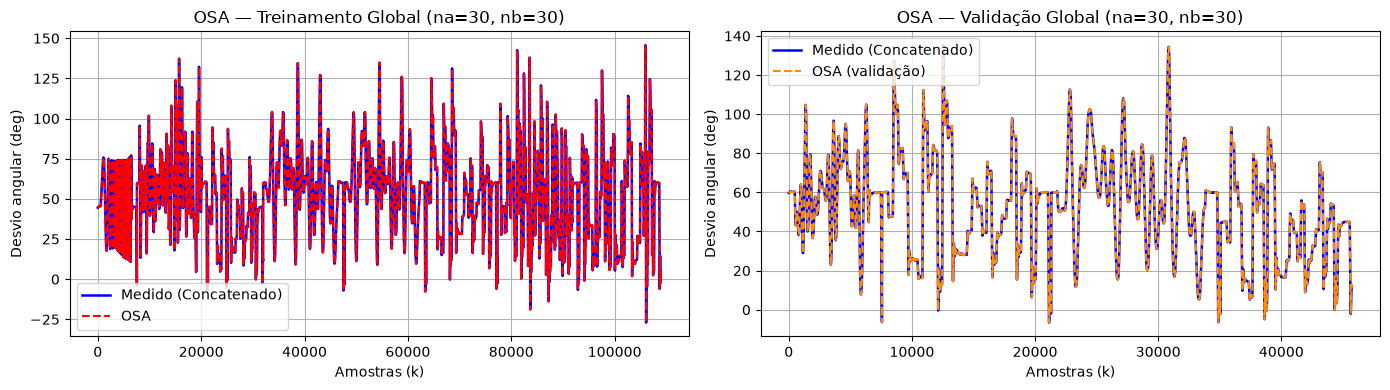

In [6]:
yhat_OSA_TRA  = Phi_TRA  @ th_hat
yhat_OSA_TEST = Phi_TEST @ th_hat

t_TRA  = np.arange(len(yhat_OSA_TRA))
t_TEST = np.arange(len(yhat_OSA_TEST))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t_TRA, y_target_TRA,  color='blue',      lw=1.8, label='Medido (Concatenado)')
axes[0].plot(t_TRA, yhat_OSA_TRA,  color='red',       lw=1.5, ls='--', label='OSA')
axes[0].set_title(f'OSA — Treinamento Global (na={na}, nb={nb})')
axes[0].set_xlabel('Amostras (k)'); axes[0].set_ylabel('Desvio angular (deg)')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_TEST, y_target_TEST,  color='blue',       lw=1.8, label='Medido (Concatenado)')
axes[1].plot(t_TEST, yhat_OSA_TEST,  color='darkorange',  lw=1.5, ls='--', label='OSA (validação)')
axes[1].set_title(f'OSA — Validação Global (na={na}, nb={nb})')
axes[1].set_xlabel('Amostras (k)'); axes[1].set_ylabel('Desvio angular (deg)')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


## 6. Simulação Free-Run — Treinamento e Validação

Executando Free-Run (treinamento global)...
Executando Free-Run (validação global)...
Concluído.


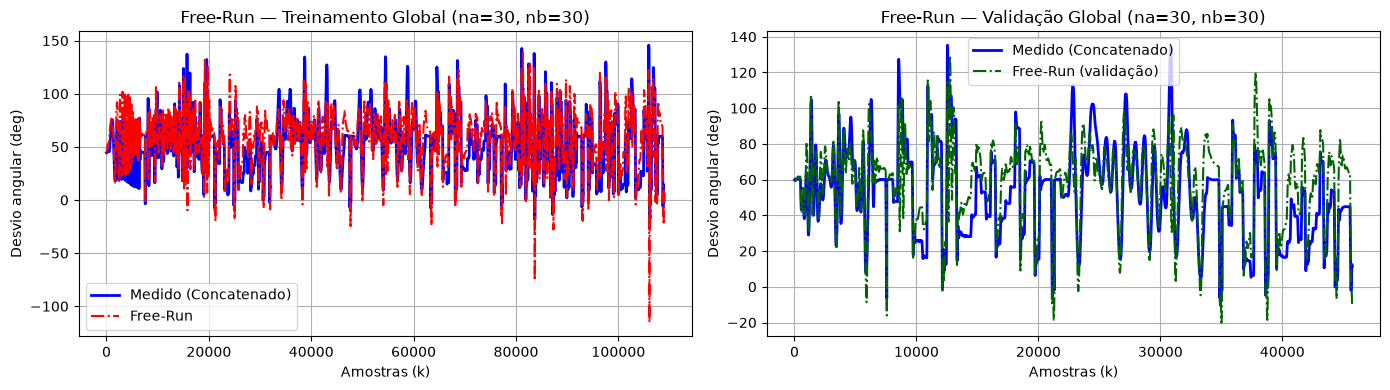

In [7]:
def free_run_global(th_hat, u_list, y_list, na, nb):
    yhat_FR_all = []
    for u, y in zip(u_list, y_list):
        yhat_FR = free_run_simulation(th_hat, u, y, na, nb)
        yhat_FR_all.append(yhat_FR)
    return np.concatenate(yhat_FR_all, axis=0)

print("Executando Free-Run (treinamento global)...")
yhat_FR_TRA  = free_run_global(th_hat, u_train_list,  y_train_list,  na, nb)
print("Executando Free-Run (validação global)...")
yhat_FR_TEST = free_run_global(th_hat, u_val_list, y_val_list, na, nb)
print("Concluído.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t_TRA, y_target_TRA,  color='blue',  lw=2.0, label='Medido (Concatenado)')
axes[0].plot(t_TRA, yhat_FR_TRA,   color='red',   lw=1.5, ls='-.', label='Free-Run')
axes[0].set_title(f'Free-Run — Treinamento Global (na={na}, nb={nb})')
axes[0].set_xlabel('Amostras (k)'); axes[0].set_ylabel('Desvio angular (deg)')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_TEST, y_target_TEST,  color='blue',      lw=2.0, label='Medido (Concatenado)')
axes[1].plot(t_TEST, yhat_FR_TEST,   color='darkgreen', lw=1.5, ls='-.', label='Free-Run (validação)')
axes[1].set_title(f'Free-Run — Validação Global (na={na}, nb={nb})')
axes[1].set_xlabel('Amostras (k)'); axes[1].set_ylabel('Desvio angular (deg)')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()


## 7. Métricas de Desempenho — Treinamento vs Validação

In [8]:
print("=" * 60)
print(f"MODELO: na={na}, nb={nb}")
print("=" * 60)
print("\n[TREINAMENTO]")
calcular_metricas(y_target_TRA,  yhat_OSA_TRA,  "OSA")
calcular_metricas(y_target_TRA,  yhat_FR_TRA,   "Free-Run")
print("\n[VALIDAÇÃO]")
calcular_metricas(y_target_TEST, yhat_OSA_TEST, "OSA")
calcular_metricas(y_target_TEST, yhat_FR_TEST,  "Free-Run")
print("=" * 60)

MODELO: na=30, nb=30

[TREINAMENTO]
  OSA                            → RMSE: 1.340595e-02  |  R²: 1.000000
  Free-Run                       → RMSE: 1.903165e+01  |  R²: 0.509318

[VALIDAÇÃO]
  OSA                            → RMSE: 1.325745e-02  |  R²: 1.000000
  Free-Run                       → RMSE: 1.638132e+01  |  R²: 0.572481


## 8. Análise de Resíduos — Espectro (FFT)

Comparação do espectro do sinal medido, predições (OSA e FR) e erros — tanto no treinamento quanto na validação.

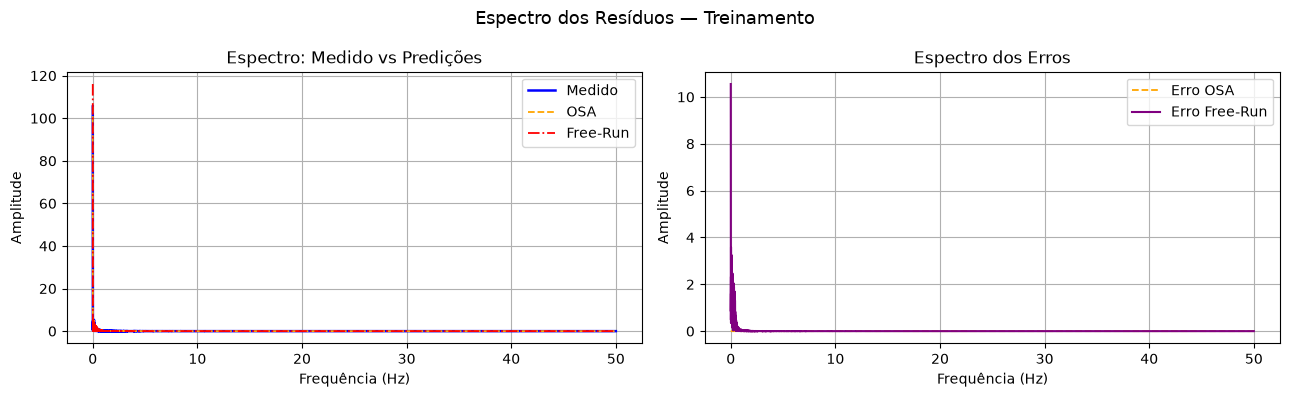

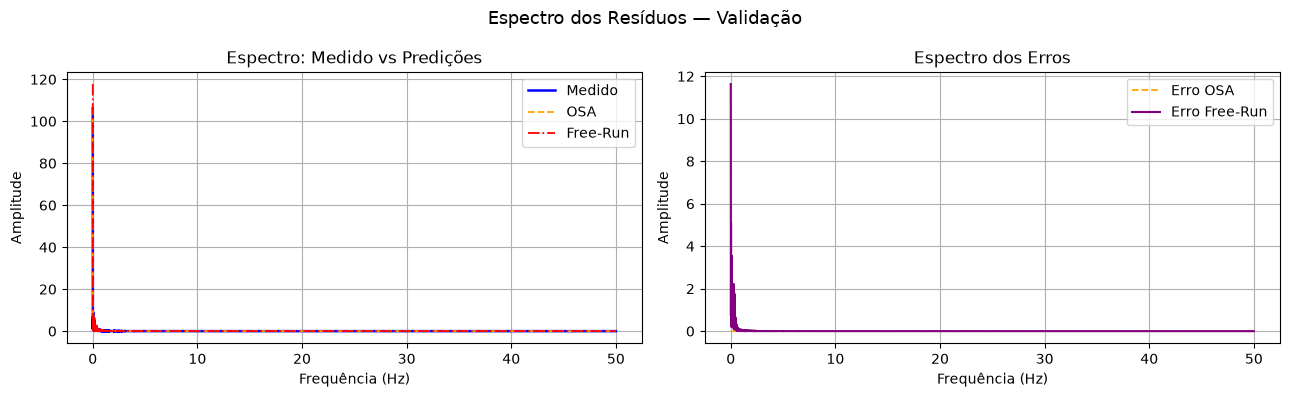

In [9]:
Ts = 0.01   # Ts_original(0.01 s) × fator de decimação(30)

for (y_real, yhat_osa, yhat_fr, titulo) in [
    (y_target_TRA,  yhat_OSA_TRA,  yhat_FR_TRA,  "Treinamento"),
    (y_target_TEST, yhat_OSA_TEST, yhat_FR_TEST, "Validação"),
]:
    erro_OSA = y_real.flatten() - yhat_osa.flatten()
    erro_FR  = y_real.flatten() - yhat_fr.flatten()

    xf, amp_med  = espectro_amplitude(y_real.flatten(),  Ts)
    _,  amp_osa  = espectro_amplitude(yhat_osa.flatten(), Ts)
    _,  amp_fr   = espectro_amplitude(yhat_fr.flatten(),  Ts)
    _,  amp_eOSA = espectro_amplitude(erro_OSA, Ts)
    _,  amp_eFR  = espectro_amplitude(erro_FR,  Ts)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Espectro dos Resíduos — {titulo}', fontsize=13)

    axes[0].plot(xf, amp_med,  label='Medido',  color='blue',   lw=1.8)
    axes[0].plot(xf, amp_osa,  label='OSA',      color='orange', lw=1.3, ls='--')
    axes[0].plot(xf, amp_fr,   label='Free-Run', color='red',    lw=1.3, ls='-.')
    axes[0].set_title('Espectro: Medido vs Predições')
    axes[0].set_xlabel('Frequência (Hz)'); axes[0].set_ylabel('Amplitude')
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(xf, amp_eOSA, label='Erro OSA',      color='orange', lw=1.3, ls='--')
    axes[1].plot(xf, amp_eFR,  label='Erro Free-Run', color='purple', lw=1.5)
    axes[1].set_title('Espectro dos Erros')
    axes[1].set_xlabel('Frequência (Hz)'); axes[1].set_ylabel('Amplitude')
    axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.show()

## 9. Comparação de Ordens do Modelo

Treinamento em TRA, avaliação em TEST (generalização real do modelo).

In [10]:
ordens_teste = [
    (1, 1), (1, 2), (2, 1), (2, 2), (2, 3), (3, 2), (3, 3), (3, 4), (4, 3), (4, 4),
    (4, 5), (5, 4), (5, 5), (6, 6), (7, 7), (8, 8), (10, 10), (10, 15), (15, 10), (12, 12),
    (15, 15), (15, 20), (20, 15), (20, 20), (20, 30), (30, 20), (25, 25), (8, 24), (24, 8), (30, 30),
    (30, 40), (40, 30), (40, 40), (30, 50), (50, 30), (40, 60), (60, 40), (50, 50), (60, 60), (70, 70),
    (80, 80), (100, 100), (150, 150), (190, 190), (120, 120), (30, 200)
]
resultados = []

for na_t, nb_t in ordens_teste:
    Phi_tra, y_tra = build_global_regression(u_train_list, y_train_list, na_t, nb_t)
    Phi_tst, y_tst = build_global_regression(u_val_list, y_val_list, na_t, nb_t)

    th_t, _, _, _ = np.linalg.lstsq(Phi_tra, y_tra, rcond=None)

    # Treinamento Global
    osa_tra = Phi_tra @ th_t
    fr_tra  = free_run_global(th_t, u_train_list,  y_train_list,  na_t, nb_t)
    # Validação Global
    osa_tst = Phi_tst @ th_t
    fr_tst  = free_run_global(th_t, u_val_list, y_val_list, na_t, nb_t)

    resultados.append({
        'na': na_t, 'nb': nb_t,
        'RMSE_OSA_TRA': np.sqrt(mean_squared_error(y_tra, osa_tra)),
        'R2_OSA_TRA':   r2_score(y_tra, osa_tra),
        'RMSE_FR_TRA':  np.sqrt(mean_squared_error(y_tra, fr_tra)),
        'R2_FR_TRA':    r2_score(y_tra, fr_tra),
        'RMSE_OSA_TST': np.sqrt(mean_squared_error(y_tst, osa_tst)),
        'R2_OSA_TST':   r2_score(y_tst, osa_tst),
        'RMSE_FR_TST':  np.sqrt(mean_squared_error(y_tst, fr_tst)),
        'R2_FR_TST':    r2_score(y_tst, fr_tst),
    })

df_res = pd.DataFrame(resultados)
print(df_res.to_string(index=False, float_format="{:.4f}".format))

# Melhor modelo pelo R² Free-Run na VALIDAÇÃO GLOBAL
best = df_res.loc[df_res['R2_FR_TST'].idxmax()]
print(f"\nMelhor configuração (R² Free-Run na Validação Global): na={int(best.na)}, nb={int(best.nb)}")
print(f"  TRA -> RMSE_FR={best.RMSE_FR_TRA:.4f}  R²_FR={best.R2_FR_TRA:.4f}")
print(f"  TST -> RMSE_FR={best.RMSE_FR_TST:.4f}  R²_FR={best.R2_FR_TST:.4f}")


 na  nb  RMSE_OSA_TRA  R2_OSA_TRA  RMSE_FR_TRA  R2_FR_TRA  RMSE_OSA_TST  R2_OSA_TST  RMSE_FR_TST  R2_FR_TST
  1   1        0.3090      0.9999      27.5458    -0.0299        0.2386      0.9999      24.6139     0.0326
  1   2        0.3076      0.9999      27.0254     0.0087        0.2378      0.9999      24.2447     0.0614
  2   1        0.0176      1.0000      21.4400     0.3761        0.0164      1.0000      19.2860     0.4061
  2   2        0.0176      1.0000      21.6143     0.3659        0.0164      1.0000      19.4292     0.3972
  2   3        0.0175      1.0000      20.9684     0.4033        0.0164      1.0000      18.8879     0.4304
  3   2        0.0173      1.0000      22.2930     0.3255        0.0161      1.0000      19.9810     0.3626
  3   3        0.0172      1.0000      21.4862     0.3734        0.0161      1.0000      19.3320     0.4033
  3   4        0.0172      1.0000      21.0162     0.4006        0.0161      1.0000      18.9338     0.4277
  4   3        0.0168      1

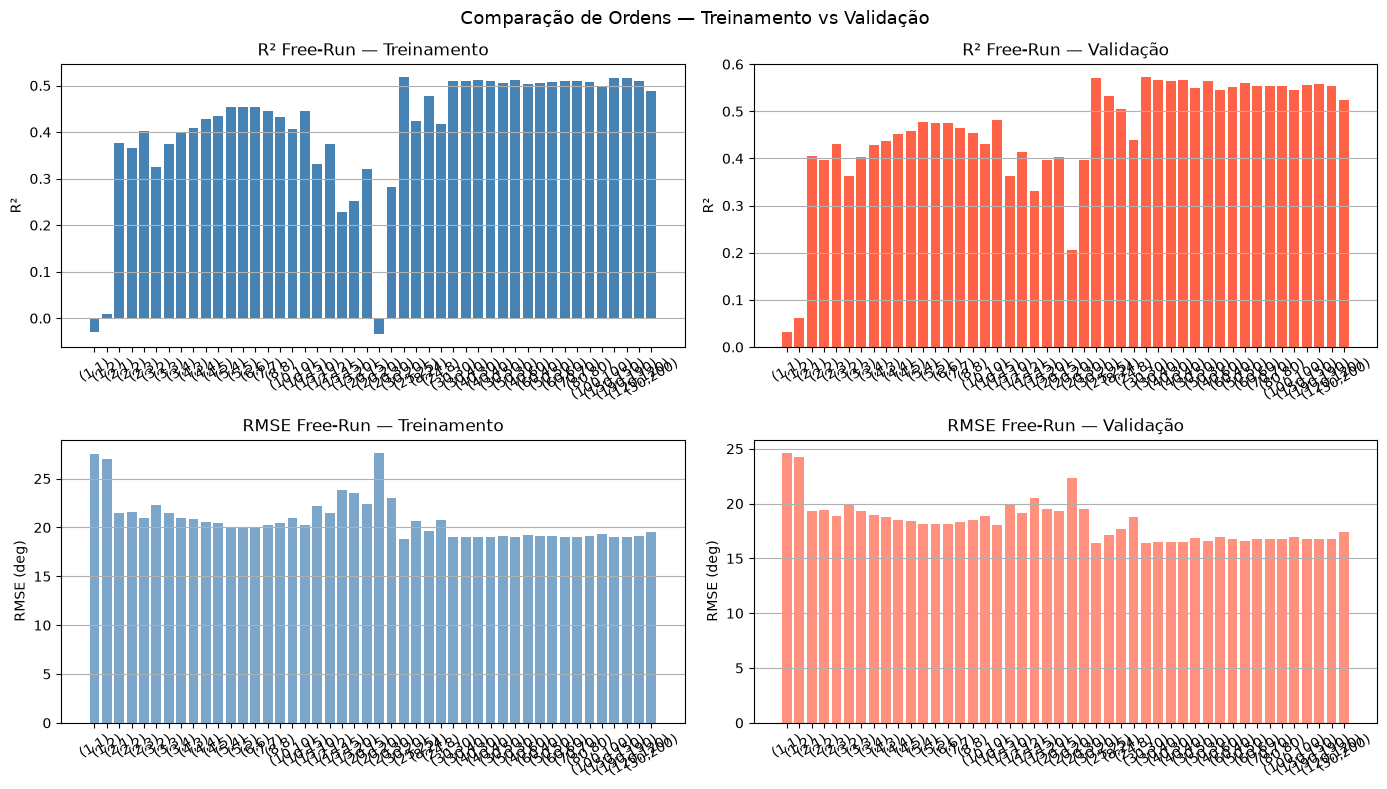

In [11]:
labels = [f"({r.na},{r.nb})" for r in df_res.itertuples()]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Comparação de Ordens — Treinamento vs Validação', fontsize=13)

axes[0,0].bar(labels, df_res['R2_FR_TRA'],  color='steelblue')
axes[0,0].set_title('R² Free-Run — Treinamento')
axes[0,0].set_ylabel('R²'); axes[0,0].tick_params(axis='x', rotation=30); axes[0,0].grid(axis='y')

axes[0,1].bar(labels, df_res['R2_FR_TST'],  color='tomato')
axes[0,1].set_title('R² Free-Run — Validação')
axes[0,1].set_ylabel('R²'); axes[0,1].tick_params(axis='x', rotation=30); axes[0,1].grid(axis='y')

axes[1,0].bar(labels, df_res['RMSE_FR_TRA'], color='steelblue', alpha=0.7)
axes[1,0].set_title('RMSE Free-Run — Treinamento')
axes[1,0].set_ylabel('RMSE (deg)'); axes[1,0].tick_params(axis='x', rotation=30); axes[1,0].grid(axis='y')

axes[1,1].bar(labels, df_res['RMSE_FR_TST'], color='tomato', alpha=0.7)
axes[1,1].set_title('RMSE Free-Run — Validação')
axes[1,1].set_ylabel('RMSE (deg)'); axes[1,1].tick_params(axis='x', rotation=30); axes[1,1].grid(axis='y')

plt.tight_layout()
plt.show()

## 10. Plot output: Real vs Estimado — Melhor Modelo

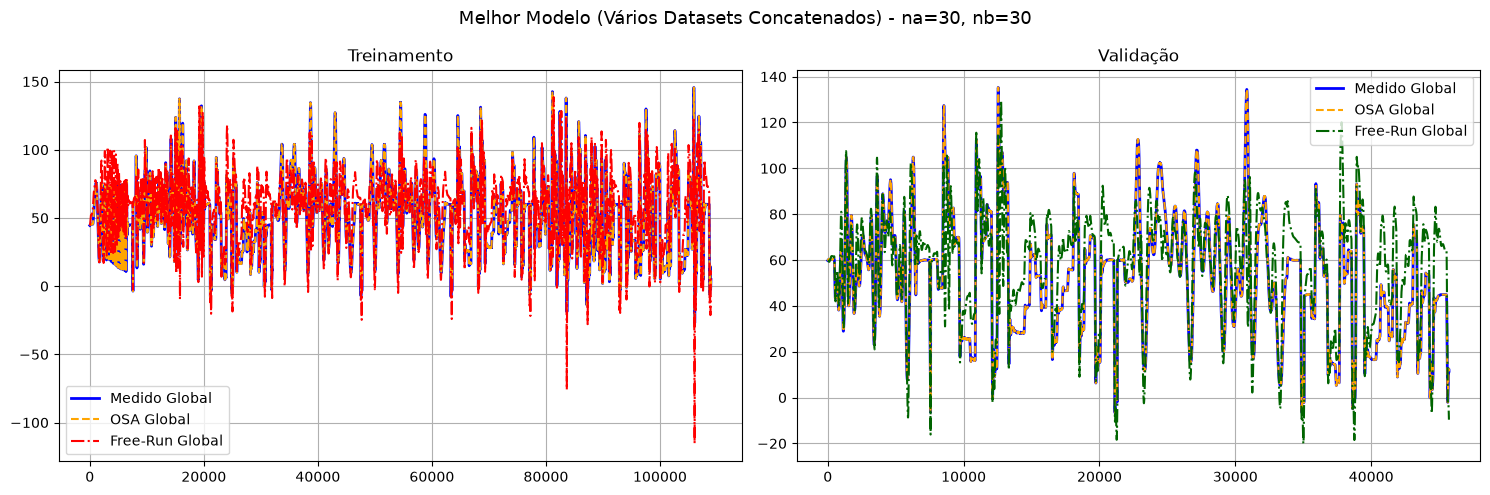


Métricas Finais - na=30, nb=30
[Treinamento]
  OSA                            → RMSE: 1.340595e-02  |  R²: 1.000000
  Free-Run                       → RMSE: 1.903165e+01  |  R²: 0.509318
[Validação]
  OSA                            → RMSE: 1.325745e-02  |  R²: 1.000000
  Free-Run                       → RMSE: 1.638132e+01  |  R²: 0.572481


(np.float64(16.381315214284157), 0.5724810620128266)

In [12]:
na_b, nb_b = int(best.na), int(best.nb)
p_b = max(na_b, nb_b)

Phi_tra_b, y_tra_b = build_global_regression(u_train_list, y_train_list, na_b, nb_b)
Phi_tst_b, y_tst_b = build_global_regression(u_val_list, y_val_list, na_b, nb_b)
th_b, _, _, _ = np.linalg.lstsq(Phi_tra_b, y_tra_b, rcond=None)

osa_tra_b = Phi_tra_b @ th_b
fr_tra_b  = free_run_global(th_b, u_train_list, y_train_list, na_b, nb_b)
osa_tst_b = Phi_tst_b @ th_b
fr_tst_b  = free_run_global(th_b, u_val_list, y_val_list, na_b, nb_b)

t_tra_b = np.arange(len(y_tra_b))
t_tst_b = np.arange(len(y_tst_b))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Melhor Modelo (Vários Datasets Concatenados) - na={na_b}, nb={nb_b}', fontsize=13)

axes[0].plot(t_tra_b, y_tra_b,  color='blue',   lw=2.0, label='Medido Global')
axes[0].plot(t_tra_b, osa_tra_b, color='orange', lw=1.5, ls='--', label='OSA Global')
axes[0].plot(t_tra_b, fr_tra_b,  color='red',    lw=1.5, ls='-.', label='Free-Run Global')
axes[0].set_title('Treinamento')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_tst_b, y_tst_b,  color='blue',      lw=2.0, label='Medido Global')
axes[1].plot(t_tst_b, osa_tst_b, color='orange',    lw=1.5, ls='--', label='OSA Global')
axes[1].plot(t_tst_b, fr_tst_b,  color='darkgreen', lw=1.5, ls='-.', label='Free-Run Global')
axes[1].set_title('Validação')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nMétricas Finais - na={na_b}, nb={nb_b}")
print("[Treinamento]")
calcular_metricas(y_tra_b, osa_tra_b, "OSA")
calcular_metricas(y_tra_b, fr_tra_b,  "Free-Run")
print("[Validação]")
calcular_metricas(y_tst_b, osa_tst_b, "OSA")
calcular_metricas(y_tst_b, fr_tst_b,  "Free-Run")


Pior configuração (R² Free-Run na Validação): na=1, nb=1
Melhor configuração (R² Free-Run na Validação): na=30, nb=30


ValueError: x and y must have same first dimension, but have shapes (22920,) and (22862,)

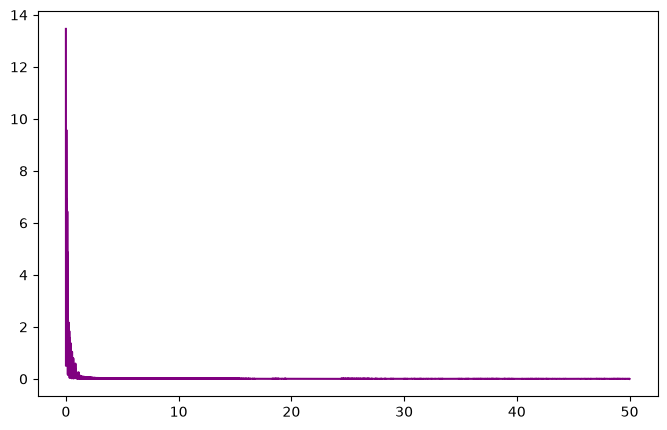

In [13]:
# Comparação do Espectro entre o Melhor e o Pior Modelo (Validação Global)
worst = df_res.loc[df_res['R2_FR_TST'].idxmin()]
print(f"Pior configuração (R² Free-Run na Validação): na={int(worst.na)}, nb={int(worst.nb)}")
print(f"Melhor configuração (R² Free-Run na Validação): na={int(best.na)}, nb={int(best.nb)}")

na_w, nb_w = int(worst.na), int(worst.nb)
p_w = max(na_w, nb_w)

# Estimar e simular o pior modelo globalmente
Phi_tra_w, y_tra_w = build_global_regression(u_train_list, y_train_list, na_w, nb_w)
Phi_tst_w, y_tst_w = build_global_regression(u_val_list, y_val_list, na_w, nb_w)
th_w, _, _, _ = np.linalg.lstsq(Phi_tra_w, y_tra_w, rcond=None)
fr_tst_w = free_run_global(th_w, u_val_list, y_val_list, na_w, nb_w)

# Sinais de erro (Validação Global)
erro_FR_best = y_tst_b.flatten() - fr_tst_b.flatten()
erro_FR_worst = y_tst_w.flatten() - fr_tst_w.flatten()

# Calcular espectros
Ts = 0.01
_, amp_erro_best = espectro_amplitude(erro_FR_best, Ts)
xf, amp_erro_worst = espectro_amplitude(erro_FR_worst, Ts)

fig, axes = plt.subplots(1, 1, figsize=(8, 5))
axes.plot(xf, amp_erro_worst, label=f'Erro Free-Run (Pior: {na_w},{nb_w})', color='purple', lw=1.5)
axes.plot(xf, amp_erro_best, label=f'Erro Free-Run (Melhor: {na_b},{nb_b})', color='green', lw=1.5, ls='--')
axes.set_title('Comparação dos Espectros de Erro (Melhor vs Pior Modelo Global)')
axes.set_xlabel('Frequência (Hz)')
axes.set_ylabel('Amplitude')
axes.legend()
axes.grid(True)
plt.show()
